In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

# 设置中文字体（防止图表乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False

In [11]:
file_path = 'C:/Users/yolo/Desktop/规定动作全部文档/2026春季《数据挖掘》考试规定动作 + 基础数据.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')
print(f"原始数据共 {len(df)} 条")
print("列名：", df.columns.tolist())  # 确认列名

原始数据共 1085 条
列名： ['标题', '标题1', '标题2', '标题3', '标题4', '标题5', '内容']


In [12]:
# 2. 筛选标题包含“数据”的岗位
df_data = df[df['标题'].str.contains('数据', na=False)].copy()
print(f"筛选出数据类岗位共 {len(df_data)} 条")

筛选出数据类岗位共 114 条


In [14]:
def extract_first_city(location_str):
    if pd.isna(location_str):
        return '未知'
    return str(location_str).split(',')[0].strip()

df_data['主要城市'] = df_data['标题2'].apply(extract_first_city)

# 提取“发布月份”
df_data['发布月份'] = pd.to_datetime(df_data['标题5']).dt.month

print("\n清洗后的前5行数据：")
print(df_data[['标题', '主要城市', '发布月份', '标题3']].head())



清洗后的前5行数据：
                             标题 主要城市  发布月份 标题3
0                  数据工艺（J73201）  北京市     6  产品
1              数据生态专家运营（J90279）  北京市     7  产品
2                数据产品经理（J86847）  北京市     7  产品
3              品牌数据产品运营（J77564）  北京市     7  产品
4  数据传输服务产品组_数据库平台研发工程师(J55962)  北京市     6  技术


In [16]:
# 技能词频统计
skills_list = [
    'Python', 'SQL', 'Java', 'C++',
    '机器学习', '深度学习', '数据挖掘',
    'Hadoop', 'Spark', '大模型', 'ETL', 'Tableau'
]

text_lower = df_data['内容'].fillna('').astype(str).str.lower()
skill_counts = {}
for skill in skills_list:
    count = text_lower.str.contains(skill.lower(), na=False, regex=False).sum()
    skill_counts[skill] = count

skill_df = pd.DataFrame(list(skill_counts.items()), columns=['技能名称', '出现次数'])
skill_df = skill_df.sort_values(by='出现次数', ascending=False)
print("\n技能出现次数统计：")
print(skill_df)



技能出现次数统计：
       技能名称  出现次数
9       大模型    16
4      机器学习    11
6      数据挖掘    11
10      ETL     7
1       SQL     3
5      深度学习     3
0    Python     2
3       C++     1
2      Java     0
7    Hadoop     0
8     Spark     0
11  Tableau     0


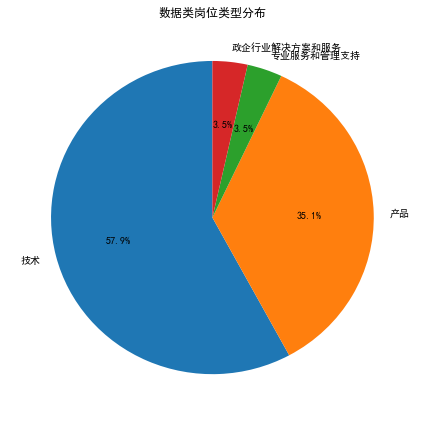

In [17]:
# 图1：岗位类型分布（饼图）
plt.figure(figsize=(6,6))
df_data['标题3'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('数据类岗位类型分布')
plt.ylabel('')
plt.tight_layout()
plt.savefig('图1_岗位类型.png', dpi=200)
plt.show()

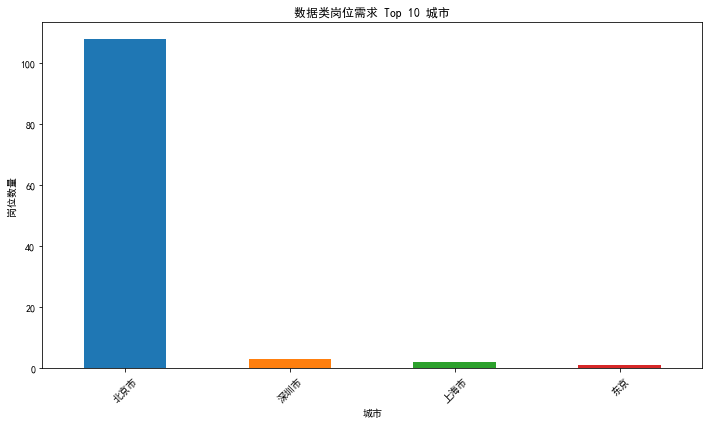

In [18]:
# 图2：主要城市需求 Top10（柱状图）
plt.figure(figsize=(10,6))
city_counts = df_data['主要城市'].value_counts().head(10)
city_counts.plot.bar()
plt.title('数据类岗位需求 Top 10 城市')
plt.xlabel('城市')
plt.ylabel('岗位数量')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('图2_城市分布.png', dpi=200)
plt.show()


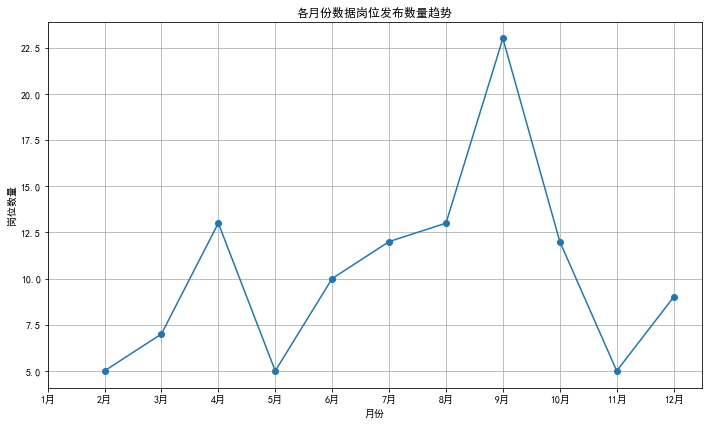

In [20]:
# 图3：各月份招聘趋势（折线图，修正 plot 调用）
plt.figure(figsize=(10,6))
monthly_counts = df_data['发布月份'].value_counts().sort_index()
monthly_counts.plot(marker='o')  # 修正这里
plt.title('各月份数据岗位发布数量趋势')
plt.xlabel('月份')
plt.ylabel('岗位数量')
plt.xticks(range(1,13), ['1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'])
plt.grid(True)
plt.tight_layout()
plt.savefig('图3_月份趋势.png', dpi=200)
plt.show()

<Figure size 720x432 with 0 Axes>

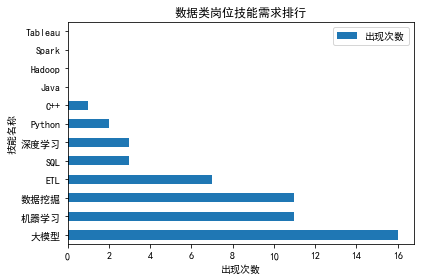

In [21]:
# 图4：技能需求排行（横向条形图）
plt.figure(figsize=(10,6))
skill_df.set_index('技能名称').plot.barh()
plt.title('数据类岗位技能需求排行')
plt.xlabel('出现次数')
plt.tight_layout()
plt.savefig('图4_技能排行.png', dpi=200)
plt.show()